# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levene, ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:
 - El dataset no tiene valores ausentes, no se observan valores nulos en ninguna columna.
 - La columna date es de tipo de dato object y debería ser datetime

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
col_categoricas=['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
print("\nConteo de categorías:")
for col in col_categoricas:
    print(f"Columna {col}")
    print(df[col].value_counts())
    print()


Conteo de categorías:
Columna landing
B    20018
A    19982
Name: landing, dtype: int64

Columna region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Columna dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Columna traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Columna user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64



In [ ]:
df[col_categoricas].describe()

,landing,region,dispositivo,traffic_source,user_type
count,40000,40000,40000,40000,40000
unique,2,5,2,4,2
top,B,Norte,Mobile,Organic,Nuevo
freq,20018,11166,24829,17987,26033


✍️ **Comentario**:
-Todas las columnas tienen valores esperados

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['landing']=='A') & (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B') & (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

Previo al t-test se realizó una prueba de varianzas iguales, en la cual se determinó que las varianzas eran diferentes, por lo que al realizar el t-test se incluyó el parámetro equal_var=False.

In [ ]:
# Prueba de varianzas iguales
l_stat, p_value_var = levene (gasto_A, gasto_B)
# Visualizar resultados
print(f"Estadístico : {l_stat}")
print(f"Valor p: {p_value_var}")

alpha = 0.05
if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False)")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True)")

Estadístico : 29.17646453202917
Valor p: 6.875301988016449e-08
Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False)


### Prueba t de Student (t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los usuarios tanto de la página A como de la B se comporta igual.
- **Hipótesis alternativa (H₁):** El gasto promedio de los usuarios de la página A y de la B es diferente.

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: El gasto promedio de los usuarios de la página A y de la B es diferente")
else:
    print("No rechazamos la hipótesis nula: El gasto promedio de los usuarios tanto de la página A como de la B se comporta igual.")


Rechazamos la hipótesis nula: El gasto promedio de los usuarios de la página A y de la B es diferente


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, hay evidencia de una diferencia en los gastos promedios de los usuarios entre la página A y B.

**Interpretación de negocio:**  

Dado que el valor p (3.63 × 10⁻²¹) es significativamente menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula, los resultados proporcionan evidencia de una diferencia estadísticamente significativa en el gasto promedio entre los usuarios que convirtieron en las páginas A y B. Dado que el estadístico t es negativo y la prueba compara el promedio de la página A menos el de la página B, los resultados indican que el gasto promedio de los usuarios de la página B es mayor que el de la página A. Sin embargo, esta prueba no cuantifica por sí sola la magnitud de la diferencia ni permite evaluar su relevancia práctica.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z (z-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas A y B
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas A y B

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Aplicar prueba
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]
z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

# Obtener tasas de porcentaje de éxito
tasa_A = exitos[0]/observaciones[0]
tasa_B = exitos[1]/observaciones[1]
print()
print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversion página B: {tasa_B:.2%}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22

Tasa de conversión página A: 12.57%
Tasa de conversion página B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, hay evidencia de una diferencia entre las tasas de conversión de las páginas A y B.

**Interpretación de negocio:**  
El z-test para comparar las tasas de conversión entre las páginas A y B produjo un estadístico Z = -9.68 y un valor p = 3.76 × 10⁻²², muy inferior al nivel de significancia de 0.05. En consecuencia, se rechaza la hipótesis nula de igualdad de tasas de conversión. Los resultados proporcionan evidencia estadística de que la página B presentó una tasa de conversión 3.39 puntos porcentuales mayor que la página A. Este resultado se basa en una muestra y la prueba no cuantifica por sí sola la magnitud del efecto ni su relevancia práctica, por lo que conviene complementar el análisis.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables fuente de tráfico y conversión (son independientes).
- **Hipótesis alternativa (H₁):** Sí existe relación entre las variables fuente de tráfico y conversión (son dependientes).

In [ ]:
# Aplicar prueba
tabla = pd.crosstab(df['traffic_source'], df['converted'])
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof:.3f}")
print(f"\nFrecuencias esperadas:")
print(expected)
print()

Estadístico Chi-cuadrado: 8.662
Valor p: 0.034
Grados de libertad: 3.000

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]



In [ ]:

tabla_pct = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100
tabla_pct


converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, hay evidencia de relación entre las variables fuente de tráfico y conversión.

**Interpretación de negocio:**  
La prueba Chi-cuadrado mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (estadístico chi-cuadrado = 8.662, p = 0.034), lo que indica que las tasas de conversión difieren entre las distintas fuentes de tráfico. Al analizar las frecuencias absolutas, se observa que Organic generó el mayor volumen de usuarios (17 987) y el mayor número de conversiones (2 480), seguido de Ads con 11 935 usuarios y 1 759 conversiones. Sin embargo, al evaluar las tasas de conversión, Email presentó la mayor proporción de usuarios convertidos en la muestra (14.99 %), seguido de Ads (14.74 %), mientras que Referral (13.88 %) y Organic (13.79 %) registraron tasas ligeramente inferiores. Estos resultados sugieren que Organic destaca por el volumen de conversiones que aporta, mientras que Email es el canal más eficiente para convertir visitantes. No obstante, las diferencias entre las tasas de conversión son reducidas (1.20 puntos porcentuales entre la mayor y la menor), por lo que, aunque la asociación es estadísticamente significativa, su relevancia práctica debe evaluarse junto con otras métricas de negocio

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables tipo de usuario y conversión (son independientes).
- **Hipótesis alternativa (H₁):** Sí existe relación entre las variables fuente de tráfico y conversión (son dependientes).

In [ ]:
# Aplicar prueba
tabla_ut = pd.crosstab(df['user_type'], df['converted'])
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_ut)
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof:.3f}")
print(f"\nFrecuencias esperadas:")
print(expected)
print()


Estadístico Chi-cuadrado: 0.513
Valor p: 0.474
Grados de libertad: 1.000

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]



In [ ]:
# Obtener tasas de porcentaje
tabla_pct_ut=pd.crosstab(df['user_type'], df['converted'], normalize='index')*100
tabla_pct_ut

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula, no existe evidencia estadística suficiente para afirmar que existe relación entre las variables tipo de usuario y conversión (son independientes)

**Interpretación de negocio:**  
Se realizó una prueba Chi-cuadrada para revisar si existe relación entre las variables tipo de usuario y conversión. Los resultados mostraron un estadístico chi-cuadrado = 0.513 y un valor p = 0.474, superior al nivel de significancia de 0.05. En consecuencia, no se rechaza la hipótesis nula, las variables son independientes. Aunque la tasa de conversión de los usuarios nuevos (14.36 %) fue ligeramente superior a la de los usuarios recurrentes (14.09 %), la diferencia observada es de apenas 0.27 puntos porcentuales y no es estadísticamente significativa. Por tanto, no se encontró evidencia estadística suficiente para afirmar que el tipo de usuario (nuevo o recurrente) esté asociado con diferencias en la probabilidad de conversión. Además, la pequeña magnitud de la diferencia observada sugiere que ambos grupos presentan un comportamiento de conversión muy similar.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

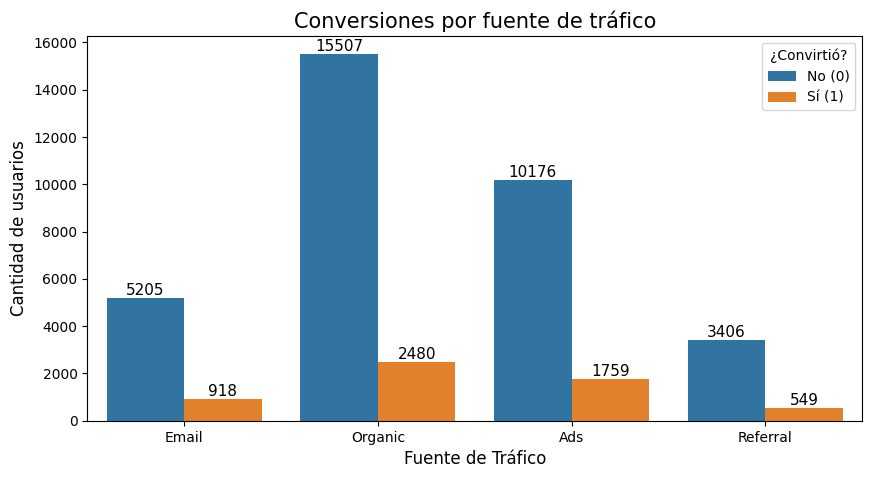

In [ ]:
# Barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(x = bar.get_x()+bar.get_width()/2,
            y = height,
            s = height,
            ha = 'center',
            va = 'bottom',
            fontsize = 11
    )
# Añadir detalles
plt.title("Conversiones por fuente de tráfico", fontsize = 15)
plt.xlabel("Fuente de Tráfico", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: En este gráfico se observa una diferencia importante en el número de usuarios que llegan por cada fuente de tráfico. Desde la perspectiva del volumen, Organic genera el mayor número absoluto de conversiones (2480), seguido por Ads (1759). Sin embargo, este resultado está influenciado por la cantidad de usuarios que recibe cada canal y no necesariamente por su eficiencia para convertir visitantes.

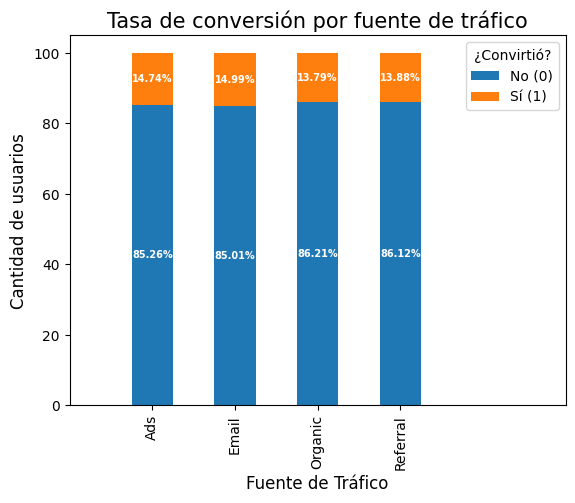

In [ ]:
#Barras apiladas
ax = tabla_pct.plot(kind='bar', stacked = True)
for bar in ax.patches:
    height = bar.get_height()
    width = bar.get_width()

    # Oculta etiquetas en segmentos vacíos o extremadamente pequeños
    if height > 0.01:
        x_pos = bar.get_x() + width / 2
        y_pos = bar.get_y() + height / 2
        ax.text(x=x_pos,
                y=y_pos,
                s=f"{height:.2f}%",
                ha='center',
                va='center',
                fontsize=7,
                color='white',
                weight='bold'
               )
# Añadir detalles
plt.title("Tasa de conversión por fuente de tráfico", fontsize = 15)
plt.xlabel("Fuente de Tráfico", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 12)
plt.xlim(-1,5)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

✍️ **Comentario**: En este gráfico se observa que Email registra la mayor tasa de conversión (14.99 %), lo que sugiere que es el canal más eficiente para convertir visitantes en clientes, a pesar de aportar un menor volumen de tráfico.
Ads combina un volumen importante de visitantes con una tasa de conversión cercana a la de Email, mientras que Referral muestra un desempeño ligeramente inferior tanto en volumen como en eficiencia.
Aunque Organic genera el mayor número de conversiones, presenta la menor tasa de conversión entre los cuatro canales. Esto indica que su elevado número de conversiones se debe principalmente al gran volumen de usuarios que recibe.
Cuando realizamos la prueba chi-cuadrada se concluyó que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión, sin embargo, las diferencias observadas en las tasas de conversión son reducidas. La mayor diferencia corresponde a Email (14.99 %) frente a Organic (13.79 %), lo que representa apenas 1.20 puntos porcentuales. Esto sugiere que, aunque la asociación es estadísticamente significativa, su magnitud práctica es limitada.

### Relación entre el tipo de usuario y la conversión

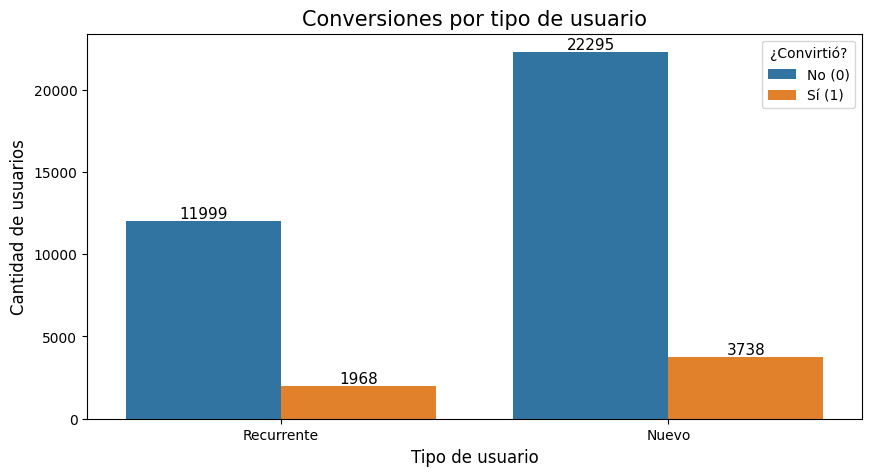

In [ ]:
# Barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(x = bar.get_x()+bar.get_width()/2,
            y = height,
            s = height,
            ha = 'center',
            va = 'bottom',
            fontsize = 11
    )
# Añadir detalles
plt.title("Conversiones por tipo de usuario", fontsize = 15)
plt.xlabel("Tipo de usuario", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**:
En este gráfico se observa que la mayor parte de los usuarios corresponde al segmento de usuarios nuevos, con un total de 26033 usuarios, frente a 13967 usuarios recurrentes.
Como consecuencia del mayor volumen de usuarios nuevos, este segmento también registra un mayor número absoluto de conversiones (3738) en comparación con los usuarios recurrentes (1968), sin embargo, este resultado está influenciado por el tamaño de cada grupo y no necesariamente indica una mayor capacidad para convertir.

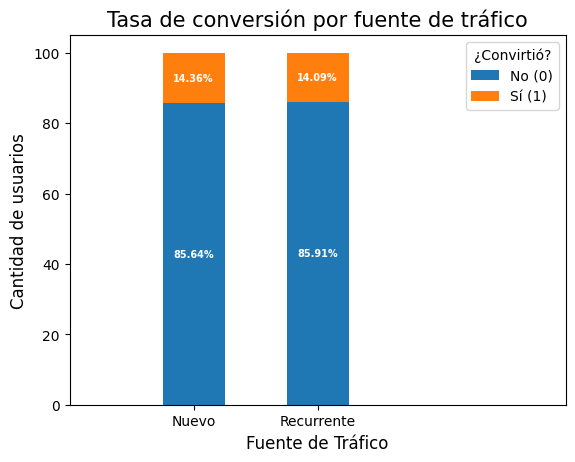

In [ ]:
#Barras apiladas
ax = tabla_pct_ut.plot(kind='bar', stacked = True)
for bar in ax.patches:
    height = bar.get_height()
    width = bar.get_width()

    # Oculta etiquetas en segmentos vacíos o extremadamente pequeños
    if height > 0.01:
        x_pos = bar.get_x() + width / 2
        y_pos = bar.get_y() + height / 2
        ax.text(x=x_pos,
                y=y_pos,
                s=f"{height:.2f}%",
                ha='center',
                va='center',
                fontsize=7,
                color='white',
                weight='bold'
               )
# Añadir detalles
plt.title("Tasa de conversión por fuente de tráfico", fontsize = 15)
plt.xlabel("Fuente de Tráfico", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 12)
plt.xlim(-1,3)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.tick_params(axis='x', rotation=0)
plt.show()

✍️ **Comentario**:
En este gráfico se observa la proporción de usuarios que convierten dentro de cada tipo de usuario.
Visualmente, ambas barras presentan prácticamente la misma distribución, la diferencia entre ambas tasas es únicamente de: 0.27 puntos porcentuales. Esta diferencia es muy pequeña y sugiere que ambos segmentos presentan un comportamiento de conversión muy similar.
El análisis gráfico coincide con los resultados de la prueba Chi-cuadrada, pues aunque, los gráficos muestran una ligera ventaja para los usuarios nuevos, la prueba estadística indica que dicha diferencia no es suficientemente grande para considerarla significativa.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El t-test mostró una diferencia estadísticamente significativa en el gasto promedio de los usuarios que realizaron una conversión entre las páginas A y B (estadístico t = -9.481; p < 0.001).
- El gasto promedio observado fue mayor entre los usuarios que convirtieron en la página B que en la página A.
  
  **Interpretación:**
- Los resultados proporcionan evidencia de una diferencia en el gasto promedio entre ambas páginas dentro de la muestra analizada. Sin embargo, esta prueba por sí sola no permite afirmar que el diseño de la página B sea la causa del mayor gasto, ni indica si la diferencia tiene un impacto económico suficientemente importante para justificar una implementación definitiva. Para apoyar una decisión de negocio sería recomendable complementar el análisis con la diferencia de medias, intervalos de confianza, tamaño del efecto y una estimación del ingreso incremental esperado.
<br>

**Tasa de conversión:**
- El z-test para dos proporciones mostró una diferencia estadísticamente significativa entre las tasas de conversión de las páginas A y B (Estadístico Z = -9.677; p < 0.001).
- La página B presentó una tasa de conversión superior a la observada en la página A.
  
  **Interpretación:**
- La evidencia estadística sugiere que, en la muestra analizada, la página B obtuvo un mejor desempeño en términos de conversión. No obstante, este resultado no implica por sí solo una relación causal.
- Además, antes de adoptar la página B como versión definitiva conviene evaluar si el incremento observado genera un beneficio económico suficiente considerando el volumen de usuarios, el costo de implementación y el retorno esperado.
---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba Chi-cuadrado mostró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (Estadístico Chi² = 8.662; p = 0.034).
- Organic aportó el mayor volumen de conversiones, mientras que Email presentó la mayor tasa de conversión (14.99 %), aunque las diferencias entre canales fueron reducidas.
  
  **Interpretación:**
- Los resultados indican que el comportamiento de conversión difiere ligeramente entre las fuentes de tráfico; sin embargo, la prueba Chi-cuadrado identifica una asociación, no una relación causal. Además, las diferencias observadas en las tasas de conversión son pequeñas, por lo que no constituyen evidencia suficiente para redistribuir el presupuesto de marketing únicamente con base en este análisis. Antes de modificar la estrategia conviene incorporar indicadores como el costo por adquisición (CPA), el retorno sobre la inversión (ROI), el ingreso generado por canal y el valor del ciclo de vida del cliente (CLV).
 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos generaron un mayor número absoluto de conversiones debido a que representan el mayor volumen de usuarios dentro de la muestra.
- Las tasas de conversión entre usuarios nuevos (14.36 %) y recurrentes (14.09 %) fueron muy similares y la prueba Chi-cuadrada no encontró diferencias estadísticamente significativas (Estadístico Chi-cuadrado = 0.513; p = 0.474).
  
  **Interpretación:**
- Con la evidencia disponible no se encontró evidencia estadística suficiente para afirmar que el tipo de usuario influya en la probabilidad de conversión. Esto sugiere que segmentar campañas únicamente entre usuarios nuevos y recurrentes probablemente no genere mejoras apreciables en la conversión. Sería más útil explorar otras variables que podrían explicar mejor el comportamiento de los clientes, el dispositivo utilizado o la ubicación geográfica del cliente.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Considerar la página B como una alternativa prometedora para futuras pruebas, ya que obtuvo mejores resultados tanto en conversión como en gasto promedio dentro de la muestra. Antes de una implementación definitiva, validar que estas diferencias se mantengan en nuevos experimentos y evaluar su impacto económico mediante métricas como el ingreso incremental y el retorno esperado.
-  Mantener el monitoreo del desempeño de los canales de adquisición considerando conjuntamente volumen de tráfico, tasa de conversión y rentabilidad. Aunque Email presentó la mayor tasa de conversión y Organic el mayor volumen de conversiones, las diferencias observadas son reducidas y no justifican, por sí solas, una redistribución del presupuesto.
-  No priorizar estrategias diferenciadas únicamente según el tipo de usuario (nuevo o recurrente), ya que no se encontraron diferencias estadísticamente significativas en la tasa de conversión entre ambos grupos. Los esfuerzos de optimización podrían orientarse hacia variables con mayor potencial explicativo.
-  Profundizar el análisis incorporando otras variables disponibles, como dispositivo, ubicación geográfica, con el fin de identificar factores adicionales que puedan influir en la conversión y orientar estrategias de marketing más efectivas.